# Lecture 02: Linear Regression and Gradient Descent

## How a model learns from prediction error

- Predicts a continuous number from a single input.
- The model equation is $\hat{y}=wx+b$.
- We measure error with Mean Squared Error (MSE).
- Gradients are computed with PyTorch `autograd`.
- **No custom `class` is used.**
- **No custom `def` is used.**


In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Settings so we always get the same results
torch.manual_seed(42)
torch.set_num_threads(1)

print("PyTorch version:", torch.__version__)


PyTorch version: 2.13.0+cpu


## 1. Create a small regression dataset

Our example problem is:

> **Can we predict an exam score from study time?**

- Input $x$: study hours
- Target $y$: exam score


In [2]:
hours = torch.tensor([1., 2., 3., 4., 5., 6., 7., 8.]).reshape(-1, 1)
scores = torch.tensor([45., 52., 58., 64., 69., 76., 82., 88.]).reshape(-1, 1)

data = pd.DataFrame({
    "study_hours": hours.squeeze().numpy(),
    "exam_score": scores.squeeze().numpy(),
})

display(data)
print("hours shape:", hours.shape)
print("scores shape:", scores.shape)


,study_hours,exam_score
0,1.0,45.0
1,2.0,52.0
2,3.0,58.0
3,4.0,64.0
4,5.0,69.0
5,6.0,76.0
6,7.0,82.0
7,8.0,88.0


hours shape: torch.Size([8, 1])
scores shape: torch.Size([8, 1])


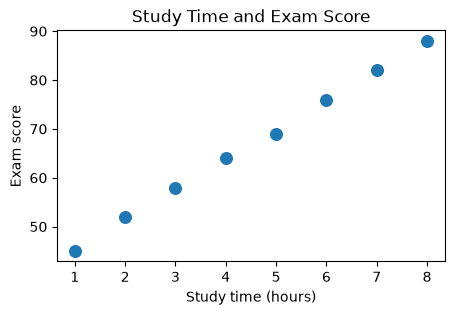

In [3]:
plt.figure(figsize=(5, 3))
plt.scatter(hours, scores, s=70)
plt.xlabel("Study time (hours)")
plt.ylabel("Exam score")
plt.title("Study Time and Exam Score")
plt.grid(False)
plt.show()


## 2. Scale the input and target to a small range

For a beginner exercise, scaling the values into a small range helps
gradient descent move smoothly.

- Study hours: divide by the maximum value (8)
- Exam score: divide by 100

The meaning of the original data does not change.


In [4]:
x = hours / hours.max()
y = scores / 100.0

scaled_data = pd.DataFrame({
    "x_scaled": x.squeeze().numpy(),
    "y_scaled": y.squeeze().numpy(),
})

display(scaled_data)
print("x range:", float(x.min()), "to", float(x.max()))
print("y range:", float(y.min()), "to", float(y.max()))


,x_scaled,y_scaled
0,0.125,0.45
1,0.250,0.52
2,0.375,0.58
3,0.500,0.64
4,0.625,0.69
5,0.750,0.76
6,0.875,0.82
7,1.000,0.88


x range: 0.125 to 1.0
y range: 0.44999998807907104 to 0.8799999952316284


## 3. Build a linear model

The model equation is:

$$
\hat{y}=wx+b
$$

- $w$: slope
- $b$: intercept
- `requires_grad=True`: tells PyTorch to track gradients for this tensor


In [5]:
w = torch.tensor([[0.0]], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# Matrix multiplication: [8, 1] @ [1, 1] -> [8, 1]
y_hat = x @ w + b

print("w:", w)
print("b:", b)
print("prediction shape:", y_hat.shape)
print("first three predictions:\n", y_hat[:3])


w: tensor([[0.]], requires_grad=True)
b: tensor([0.], requires_grad=True)
prediction shape: torch.Size([8, 1])
first three predictions:
 tensor([[0.],
        [0.],
        [0.]], grad_fn=<SliceBackward0>)


## 4. Compute the Mean Squared Error

We square each prediction error, then average them.

$$
\text{MSE}=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2
$$


In [6]:
errors = y_hat - y
squared_errors = errors ** 2
loss = squared_errors.mean()

print("first three errors:\n", errors[:3])
print("MSE loss:", loss.item())


first three errors:
 tensor([[-0.4500],
        [-0.5200],
        [-0.5800]], grad_fn=<SliceBackward0>)
MSE loss: 0.46492499113082886


## 5. Compute one gradient step

Running `loss.backward()` makes PyTorch compute:

- $\frac{\partial L}{\partial w}$
- $\frac{\partial L}{\partial b}$

Moving in the **opposite** direction of the gradient decreases the loss.


In [7]:
loss.backward()

print("gradient of w:", w.grad)
print("gradient of b:", b.grad)

learning_rate = 0.1

with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

# Reset the gradients before the next computation
w.grad.zero_()
b.grad.zero_()

print("updated w:", w)
print("updated b:", b)


gradient of w: tensor([[-0.8306]])
gradient of b: tensor([-1.3350])
updated w: tensor([[0.0831]], requires_grad=True)
updated b: tensor([0.1335], requires_grad=True)


## 6. The full training loop

Every epoch repeats these five steps:

1. Predict
2. Calculate loss
3. Backward
4. Update parameters
5. Reset gradients


In [8]:
# Start again from zero
w = torch.tensor([[0.0]], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

learning_rate = 0.1; epochs = 800; loss_history = []
for epoch in range(epochs):
    # 1. Predict
    y_hat = x @ w + b

    loss = ((y_hat - y) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    w.grad.zero_()
    b.grad.zero_()

    loss_history.append(loss.item())
    
    if epoch % 200 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.6f}")  

print("\nFinal w:", w.item())
print("Final b:", b.item())


epoch   0 | loss 0.464925
epoch 200 | loss 0.000036
epoch 400 | loss 0.000016
epoch 600 | loss 0.000016
epoch 799 | loss 0.000016

Final w: 0.48570477962493896
Final b: 0.39429140090942383


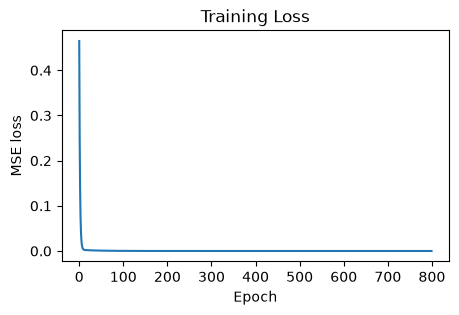

In [9]:
plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training Loss")
plt.grid(False)
plt.show()


## 7. Look at the learned line

The model learned on scaled values. For the plot, we convert the
predictions back to the original exam-score scale.


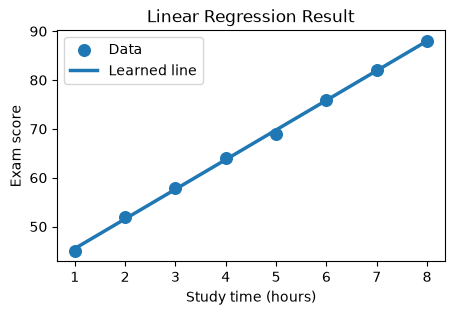

Approximate score increase per hour: 6.07
Approximate intercept: 39.43


In [10]:
with torch.no_grad():
    predicted_scores = (x @ w + b) * 100.0
plt.figure(figsize=(5, 3))
plt.scatter(hours, scores, s=70, label="Data")
plt.plot(hours, predicted_scores, linewidth=2.5, 
         label="Learned line")
plt.xlabel("Study time (hours)")
plt.ylabel("Exam score")
plt.title("Linear Regression Result")
plt.legend()
plt.grid(False)
plt.show()

# Slope and intercept in the original units
score_per_hour = 100.0 * w.item() / hours.max().item()
score_intercept = 100.0 * b.item()

print(f"Approximate score increase per hour: {score_per_hour:.2f}")
print(f"Approximate intercept: {score_intercept:.2f}")


## 8. Predict a new value

Predict the score for a student who studied 6.5 hours.


In [11]:
new_hours = torch.tensor([[6.5]])
new_x = new_hours / hours.max()

with torch.no_grad():
    new_score = (new_x @ w + b) * 100.0

print(f"Study time: {new_hours.item():.1f} hours")
print(f"Predicted score: {new_score.item():.1f}")


Study time: 6.5 hours
Predicted score: 78.9


## 9. Compare learning rates

- Too small: training is slow.
- Just right: loss decreases steadily.
- Too large: loss can grow or diverge.


learning rate=0.01 | completed epochs=120
learning rate=0.10 | completed epochs=120
learning rate=0.80 | completed epochs=109


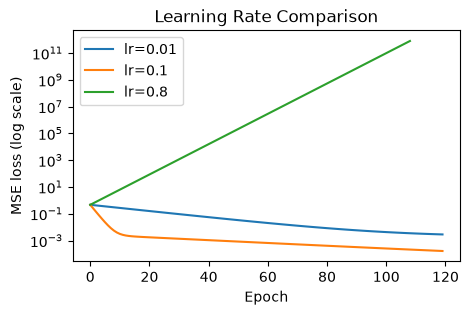

In [12]:
learning_rates = [0.01, 0.10, 0.80]
loss_by_lr = {}

for lr in learning_rates:
    temp_w = torch.tensor([[0.0]], requires_grad=True)
    temp_b = torch.tensor([0.0], requires_grad=True)
    temp_history = []
    for epoch in range(120):
        temp_prediction = x @ temp_w + temp_b
        temp_loss = ((temp_prediction - y) ** 2).mean()
        if not torch.isfinite(temp_loss) or temp_loss.item() > 1e12:
            break

        temp_loss.backward()
        with torch.no_grad():
            temp_w -= lr * temp_w.grad
            temp_b -= lr * temp_b.grad

        temp_w.grad.zero_();  temp_b.grad.zero_()
        temp_history.append(temp_loss.item())

    loss_by_lr[lr] = temp_history
    print(f"learning rate={lr:.2f} | completed epochs={len(temp_history)}") 

plt.figure(figsize=(5, 3))
for lr, history in loss_by_lr.items():
    plt.plot(history, label=f"lr={lr}")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss (log scale)")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(False)
plt.show()


## 10. Key takeaways

- Linear model: $\hat{y}=wx+b$
- Regression loss: Mean Squared Error
- `loss.backward()`: computes gradients
- Parameter update: $\theta \leftarrow \theta-\eta\nabla L$
- Learning rate $\eta$: how big a step to take each time

### Check your understanding

1. If $w$ gets larger, how does the slope of the line change?
2. If $b$ gets larger, which direction does the line shift?
3. What can go wrong if the learning rate is too large?


## Practice Problem

Scenario: A small coffee shop recorded the outdoor temperature
(°C) and the number of iced coffees sold that day.

| Temperature (°C) | Iced coffees sold |
|---|---|
| 15 | 10 |
| 18 | 18 |
| 21 | 25 |
| 24 | 33 |
| 27 | 40 |
| 30 | 48 |
| 33 | 55 |
| 36 | 63 |

- Using the same method as this lecture (scale the data, build a
linear model $\hat{y}=wx+b$, 
- train with gradient descent for 800
epochs at learning_rate=0.1), do the following:

1. Train a linear model to predict iced coffees sold from temperature.
2. Plot the training loss curve.
3. Plot the data together with the learned line.
4. Predict how many iced coffees will be sold at 29°C.


### Solution

Final w: 0.8876787424087524
Final b: -0.263507217168808
Final loss: 1.4504300452244934e-05


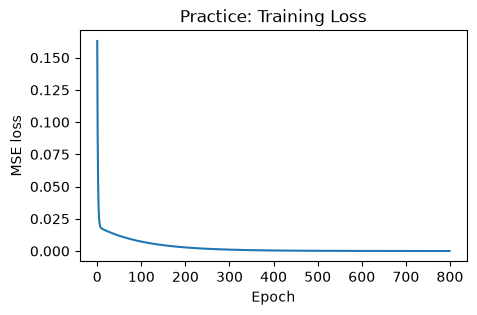

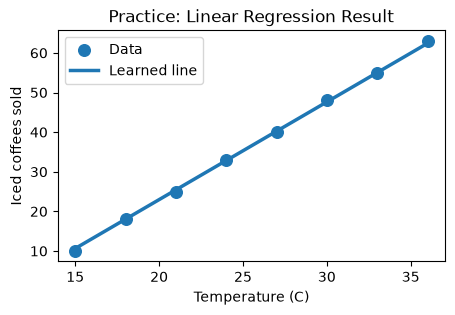

Temperature: 29.0 C
Predicted iced coffees sold: 45.2


In [13]:
# ----- Data -----
temperature = torch.tensor([15., 18., 21., 24., 27., 30., 33., 36.]).reshape(-1, 1)
coffees_sold = torch.tensor([10., 18., 25., 33., 40., 48., 55., 63.]).reshape(-1, 1)

# ----- Scale to a small range, the same way as the lecture -----
x_p = temperature / temperature.max()
y_p = coffees_sold / 100.0

# ----- Train a linear model -----
w_p = torch.tensor([[0.0]], requires_grad=True)
b_p = torch.tensor([0.0], requires_grad=True)

learning_rate = 0.1
epochs = 800
loss_history_p = []

for epoch in range(epochs):
    y_hat_p = x_p @ w_p + b_p
    loss_p = ((y_hat_p - y_p) ** 2).mean()

    loss_p.backward()

    with torch.no_grad():
        w_p -= learning_rate * w_p.grad
        b_p -= learning_rate * b_p.grad

    w_p.grad.zero_()
    b_p.grad.zero_()

    loss_history_p.append(loss_p.item())

print("Final w:", w_p.item())
print("Final b:", b_p.item())
print("Final loss:", loss_history_p[-1])

# ----- Plot the training loss -----
plt.figure(figsize=(5, 3))
plt.plot(loss_history_p)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Practice: Training Loss")
plt.grid(False)
plt.show()

# ----- Plot the data with the learned line -----
with torch.no_grad():
    predicted_sales = (x_p @ w_p + b_p) * 100.0

plt.figure(figsize=(5, 3))
plt.scatter(temperature, coffees_sold, s=70, label="Data")
plt.plot(temperature, predicted_sales, linewidth=2.5, label="Learned line")
plt.xlabel("Temperature (C)")
plt.ylabel("Iced coffees sold")
plt.title("Practice: Linear Regression Result")
plt.legend()
plt.grid(False)
plt.show()

# ----- Predict for a new temperature -----
new_temperature = torch.tensor([[29.0]])
new_x_p = new_temperature / temperature.max()

with torch.no_grad():
    predicted_coffees = (new_x_p @ w_p + b_p) * 100.0

print(f"Temperature: {new_temperature.item():.1f} C")
print(f"Predicted iced coffees sold: {predicted_coffees.item():.1f}")
